# Figure 2: DASIT iRFP Distribution - mod/DNA/Lenti


In [45]:
import rushd as rd
import matplotlib
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
from textwrap import wrap
from statannotations.Annotator import Annotator
from pathlib import Path
from scipy.optimize import curve_fit
from scipy.stats import poisson
import scipy

In [61]:
# Set paths to the experiment folder and where to find the data
base_path = rd.datadir/'data'/'attune'/'Mary'

Plates = {'2026.07.31_iRFP_lenti': ['Plate1'], #Lenti
        '2026.07.02_exp61': ['Plate1','Plate2'], #Plasmid-1-2
        '2026.07.02_exp60': ['Plate1', 'Plate2'], #Plasmid-3-4
}

exp_path = []
yaml_path = []

for i in Plates:
    for j in Plates[i]:
        exp_path.append(base_path/i/j/'export_singlets')
        yaml_path.append(base_path/i/j/'export_singlets'/'well_metadata2.yaml')

output_path = rd.rootdir/'output'/'Figure_2_selectivity'
cache_path = rd.rootdir/'output'/'Figure_2_selectivity'/'data_iRFP.gzip'

plates_dict = pd.DataFrame({
    'data_path' : [exp for exp in exp_path],
    'yaml_path' : [yaml for yaml in yaml_path]
})

display(plates_dict)

,data_path,yaml_path
0,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
1,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
2,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
3,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
4,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...


In [95]:
#Load data
data = pd.DataFrame()
if cache_path.is_file(): data = pd.read_parquet(cache_path)
else:
    channel_list = ['mRuby2-A', 'mRuby2-H','mGL-H','mGL-A', 'iRFP670-A','iRFP670-H', 'FSC-A', 'SSC-A']
    data = rd.flow.load_groups_with_metadata(plates_dict,columns=channel_list) #Could add in columns=channel_list here to get specific columns

    # Remove NaN values
    data.dropna(inplace=True)

    # Save data in the cache path for easier loading next time
    data.to_parquet(rd.outfile(cache_path))


In [98]:
display(data[(data['Date'] == '2026.07.02.b') & (data['Puro'] == '0x' )])

,reporter,Puro,Puro#,Deliver,Plasmid,Date,well,population,FSC-A,SSC-A,mGL-A,mGL-H,iRFP670-A,iRFP670-H,mRuby2-A,mRuby2-H
2099913,pKG04437,0x,0.0,Plasmid,1x,2026.07.02.b,A1,Single Cells,437512,167996,-5.0,64,27.0,85,151,77
2099914,pKG04437,0x,0.0,Plasmid,1x,2026.07.02.b,A1,Single Cells,486343,293170,26.0,69,69.0,75,78,83
2099915,pKG04437,0x,0.0,Plasmid,1x,2026.07.02.b,A1,Single Cells,398526,128037,121.0,71,86.0,82,-70,75
2099916,pKG04437,0x,0.0,Plasmid,1x,2026.07.02.b,A1,Single Cells,545251,264023,112.0,67,8.0,93,62,76
2099917,pKG04437,0x,0.0,Plasmid,1x,2026.07.02.b,A1,Single Cells,453419,454297,52.0,58,3528.0,2697,35,71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7317008,pKG05003,0x,0.0,Plasmid,1x,2026.07.02.b,H7,Single Cells,294196,184998,619.0,195,1411.0,1136,59,58
7317009,pKG05003,0x,0.0,Plasmid,1x,2026.07.02.b,H7,Single Cells,401814,241186,44.0,123,22.0,31,32,75
7317010,pKG05003,0x,0.0,Plasmid,1x,2026.07.02.b,H7,Single Cells,358139,211184,-49.0,52,8565.0,6967,596,456
7317011,pKG05003,0x,0.0,Plasmid,1x,2026.07.02.b,H7,Single Cells,365534,310270,93.0,124,11336.0,9535,-11,51


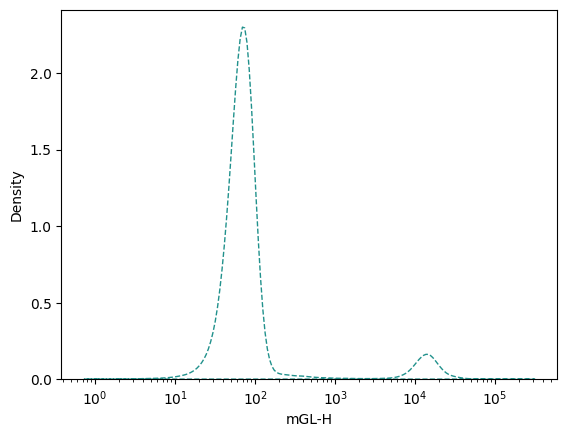

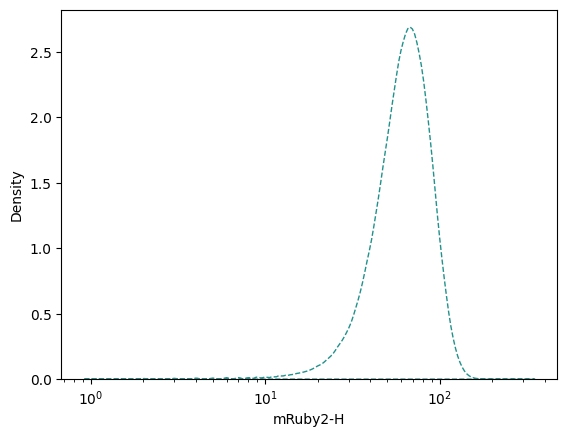

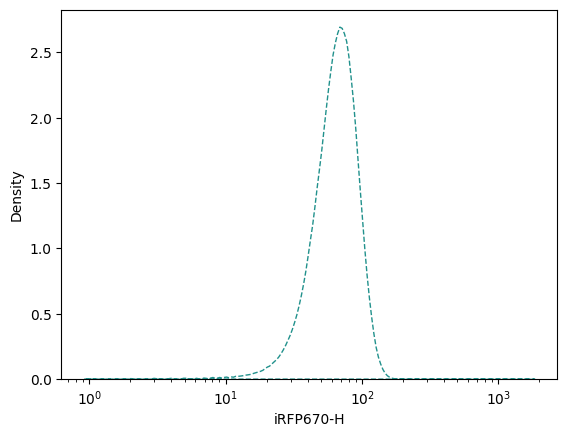

In [64]:
parameters = np.array(['mGL-H', 'mRuby2-H', 'iRFP670-H'])
for param in parameters:
    untransfected = data[(data['reporter'] == 'Untransfected')& (data[param] > 0)]
    g = plt.figure()
    sns.kdeplot(untransfected, x=param,hue='reporter',log_scale=True,legend=False,fill=True,common_norm=False,palette='viridis', alpha = 0, linestyle = '--')

In [112]:
data['conds'] = data['reporter'] +'.'+ data['Deliver'] 
display(data)

,reporter,Puro,Puro#,Deliver,Plasmid,Date,well,population,FSC-A,SSC-A,mGL-A,mGL-H,iRFP670-A,iRFP670-H,mRuby2-A,mRuby2-H,iRFP670_cat,conds
0,pKG05002,0x,0.0,Lenti,1x,2026.07.31.x,A1,Single Cells,463729,147787,-22.0,65,107.0,99,-3,47,iRFP670-,pKG05002.Lenti
1,pKG05002,0x,0.0,Lenti,1x,2026.07.31.x,A1,Single Cells,486842,197250,-38.0,54,28540.0,20456,-86,61,iRFP670+,pKG05002.Lenti
2,pKG05002,0x,0.0,Lenti,1x,2026.07.31.x,A1,Single Cells,569925,233442,146.0,92,-105.0,33,-62,55,iRFP670-,pKG05002.Lenti
3,pKG05002,0x,0.0,Lenti,1x,2026.07.31.x,A1,Single Cells,448998,420921,38.0,86,20569.0,13485,11,88,iRFP670+,pKG05002.Lenti
4,pKG05002,0x,0.0,Lenti,1x,2026.07.31.x,A1,Single Cells,534490,342837,-39.0,85,3166.0,2157,-63,74,iRFP670+,pKG05002.Lenti
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19097725,pKG05003,0x,0.0,Plasmid,0.1x,2026.07.02.xx,H9,Single Cells,298796,138615,-14.0,50,49.0,109,88,88,iRFP670-,pKG05003.Plasmid
19097726,pKG05003,0x,0.0,Plasmid,0.1x,2026.07.02.xx,H9,Single Cells,165894,176331,81.0,103,-59.0,64,-15,46,iRFP670-,pKG05003.Plasmid
19097727,pKG05003,0x,0.0,Plasmid,0.1x,2026.07.02.xx,H9,Single Cells,350031,282455,101.0,103,53.0,74,22,81,iRFP670-,pKG05003.Plasmid
19097728,pKG05003,0x,0.0,Plasmid,0.1x,2026.07.02.xx,H9,Single Cells,451891,245852,-15.0,32,-80.0,31,-157,24,iRFP670-,pKG05003.Plasmid


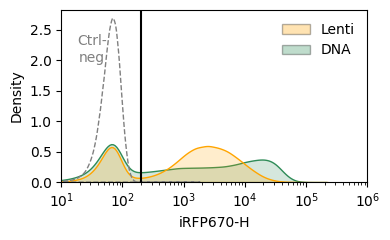

In [78]:
order = ['pKG05003.Lenti', 'pKG05003.Plasmid']

label_map = {
    'pKG05003.Lenti':'Lenti',
    'pKG05003.Plasmid':'DNA',
    'Untransfected.Plasmid': 'Ctl-Neg'
}
untransfected = data[(data['conds'] == 'Untransfected.Plasmid') & (data['iRFP670-H'] > 0) & (data['Plasmid'] == '0x')]
data_new = data[(data['conds'].isin(order)) & (data['iRFP670-H'] > 0)& (data['Plasmid'] == '1x') & (data['Puro'] == '0x')]

g = plt.figure(figsize=(4,2.5))
palette = {'Untransfected.Plasmid': 'grey',
        'pKG05003.Lenti': 'orange',
        'pKG05003.Plasmid': 'seagreen'}
ax = sns.kdeplot(data_new, x='iRFP670-H',hue='conds',log_scale=(True,False),legend=False,fill=True,common_norm=False,palette=palette, alpha = 0.2)
sns.kdeplot(untransfected, x='iRFP670-H',hue='conds',log_scale=(True,False),legend=False,fill=True,common_norm=False,palette=palette, alpha = 0, linestyle = '--')
ax.axvline(x = 200, color='black', linestyle='-')
ax.annotate('Ctrl-\nneg', (0.1, 0.7), color='grey', xycoords='axes fraction', ha='center')

# Add custom legend
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='orange', alpha = 0.3, edgecolor='black', label='Lenti'),
    Patch(facecolor='seagreen', alpha = 0.3,  edgecolor='black', label='DNA')
]
# Adjust limits
iRFP_lim = (10, 1*10**6)
for sub_ax in plt.gcf().get_axes():
    sub_ax.set_xlim(iRFP_lim)

g.tight_layout()
ax.legend(handles=legend_elements, frameon=False)
# plt.title(f'293Ts Plasmid titration, {label_map[plasmid]}')
# g = g.get_figure()
# title = str(plasmid) + '_iRFP_mRuby2.svg'
# g.savefig(rd.outfile(output_path/title),bbox_inches='tight')

In [113]:
data_subset = data[(data['reporter'] == 'pKG05003') & (data['Plasmid'] == '1x') & (data['Puro'] == '0x')].copy()

In [114]:
iRFP670_H_thresh = 2.5e2
# Categorize cells based on iRFP670_thresh
data.loc[:, 'iRFP670_cat'] = 'iRFP670-'
data.loc[(data['iRFP670-H'] > iRFP670_H_thresh), 'iRFP670_cat'] = 'iRFP670+'

# Get total counts and percent of GFP-H+
group = [ 'reporter', 'conds', 'Date','Deliver','Plasmid','Puro']
count_df_reps = data_subset.groupby([*group, 'well', 'iRFP670_cat'])[
    'iRFP670-H'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no iRFP-H+ rather than dropping row
percent_df_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'well']).transform('sum')).reset_index(name='percent')
data_iRFP670_count_reps = count_df_reps.reset_index()

# Extract just the iRFP670+
data_iRFP670_percent_reps = percent_df_reps.loc[(percent_df_reps['iRFP670_cat'] == 'iRFP670+')]
data_iRFP670_count_reps = data_iRFP670_count_reps.loc[(data_iRFP670_count_reps['iRFP670_cat'] == 'iRFP670+')]

In [115]:
df_infected = data_subset[data_subset['iRFP670_cat'] == 'iRFP670+'].copy()

In [116]:
# Calc gmean
y = 'iRFP670-H'
group = [ 'reporter', 'Date','Deliver']
df_gmean = df_infected.groupby([*group])[y].apply(scipy.stats.gmean).unstack(fill_value=0).stack().reset_index(name=y+' (gmean)')

# Take out ctrl
df_gmean = df_gmean.loc[df_gmean.reporter != 'Untransfected'] 

# Add back in ctrl
df_ctrl_gmean = data_subset.loc[data[y]>0].groupby(group)[y].apply(scipy.stats.gmean).reset_index(name=y+' (gmean)')
df_ctrl_gmean = df_ctrl_gmean.loc[df_ctrl_gmean.reporter == 'Ctrl-neg']

# Final gmean df with positive cells and ctrl neg
df_gmean = pd.concat([df_gmean, df_ctrl_gmean], ignore_index=True)


In [117]:
df_subset = df_gmean[(df_gmean['reporter'] == 'pKG05003')].copy()
display(df_subset)

,reporter,Date,Deliver,iRFP670-H (gmean)
0,pKG05003,2026.07.02.b,Lenti,0.000000
1,pKG05003,2026.07.02.b,Plasmid,3516.509944
2,pKG05003,2026.07.02.bb,Lenti,0.000000
3,pKG05003,2026.07.02.bb,Plasmid,4022.857479
4,pKG05003,2026.07.02.x,Lenti,0.000000
5,pKG05003,2026.07.02.x,Plasmid,5991.490900
6,pKG05003,2026.07.02.xx,Lenti,0.000000
7,pKG05003,2026.07.02.xx,Plasmid,4701.152803
8,pKG05003,2026.07.31.x,Lenti,2543.595061
9,pKG05003,2026.07.31.x,Plasmid,0.000000


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

pKG05003.Lenti vs. pKG05003.Plasmid: t-test independent samples with Bonferroni correction, P_val:1.179e-01 t=-1.647e+00
                                                              iRFP670-H (gmean)
reporter conds            Date          Deliver Plasmid Puro                   
Control  Control.Plasmid  2026.07.02.b  Plasmid 1x      0x           291.126872
                          2026.07.02.bb Plasmid 1x      0x          4777.715673
pKG04405 pKG04405.Plasmid 2026.07.02.x  Plasmid 0.1x    0x           477.361652
                                                0.5x    0x          1495.095816
                                                1x      0x          3695.695230
...                                                                         ...
pKG05003 pKG05003.Plasmid 2026.07.02.x  Plasmid

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_34544\2012121597.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_map[l] for l in order])


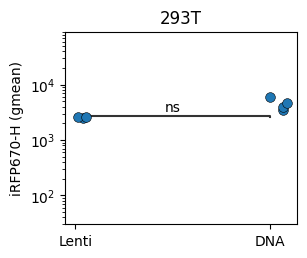

In [82]:
# Plotting params
x = 'conds'
y = 'iRFP670-H'
order = ['pKG05003.Lenti', 'pKG05003.Plasmid']

label_map = {
    'pKG05003.Lenti':'Lenti',
    'pKG05003.Plasmid':'DNA',
    'Untransfected.Plasmid': 'Ctl-Neg'
}

untransfected = df_gmean[(df_gmean['conds'] == 'Untransfected.Plasmid') & (df_gmean['Plasmid'] == '0x')]
data_new = df_gmean[(df_gmean['conds'].isin(order)) &  (df_gmean['Plasmid'] == '1x') & (df_gmean['Puro'] == '0x')]

palette = {'Untransfected.Plasmid': 'grey',
        'pKG05003.Lenti': 'orange',
        'pKG05003.Plasmid': 'seagreen'}

# Conditions
fig, ax = plt.subplots(1, 1, figsize=(3, 2.5))

# Plot geometric means
sns.stripplot(
    ax=ax, data=data_new,
    x=x, y=y+' (gmean)',
    order=order,
    dodge=False, 
    size=7,
    edgecolor='black', linewidth=0.4)

# Plot ctrl-neg
# ax.axhline(float(df_gmean.loc[df_gmean.conds == 'Untransfected.Plasmid', y+' (gmean)']), 0, 1, color='grey', linestyle='--')

# # Add in stats
# # Pairs for stats comp
pairs = [('pKG05003.Lenti', 'pKG05003.Plasmid')]
annot = Annotator(ax=ax,
    data=df_gmean, pairs=pairs,
    x=x, y=y+' (gmean)',
    order=order)
annot.configure(test='t-test_ind', comparisons_correction='Bonferroni', text_format='star', loc='inside', verbose=2)
annot.apply_test().annotate(line_offset_to_group=0)


# # Adjust labels
ax.set_xticklabels([label_map[l] for l in order])
ax.set_xlabel('')
# ax.ticklabel_format(axis='y', style='sci', scilimits=(1, 2))
ax.set_yscale('log')
ax.set_ylim((3e1, 9e4))
# ax.yaxis.set_label_text('iRFP670\n(gmean)')
# sns.move_legend(ax, title="", loc="upper left", bbox_to_anchor=(1, 1), frameon=False)
plt.title('293T')

print(df_gmean.groupby([ 'reporter', 'conds', 'Date','Deliver','Plasmid','Puro']).mean())
